In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
adata1 = sc.read_h5ad(r"C:\Users\annam\Dissertation 2026\Data\Raw\GSE114725_raw.h5ad")

adata2 = sc.read_h5ad(r"C:\Users\annam\Dissertation 2026\Data\Raw\GSE176078_raw.h5ad")

print(adata1)
print(adata2)

AnnData object with n_obs × n_vars = 47016 × 14875
    obs: 'patient', 'tissue', 'replicate', 'cluster'
AnnData object with n_obs × n_vars = 100064 × 29733
    obs: 'Unnamed: 0', 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'subtype', 'celltype_subset', 'celltype_minor', 'celltype_major', 'dataset'


In [4]:
for adata in [adata1, adata2]:
    adata.var["mt"] = adata.var_names.str.startswith("MT-")
    sc.pp.calculate_qc_metrics(
        adata,
        qc_vars=["mt"],
        percent_top=None,
        log1p=False,
        inplace=True
    )

print(adata1.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head())
print(adata2.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head())

         n_genes_by_counts  total_counts  pct_counts_mt
cell_id                                                
246                    240         401.0       1.246883
260                    509         946.0       6.976744
346                    443         839.0       5.959476
188                    369         541.0       5.545287
33                     275         407.0       3.439803
                          n_genes_by_counts  total_counts  pct_counts_mt
CID3586_AAGACCTCAGCATGAG               1689        4581.0       1.506221
CID3586_AAGGTTCGTAGTACCT                779        1726.0       5.793743
CID3586_ACCAGTAGTTGTGGCC                514        1229.0       1.383238
CID3586_ACCCACTAGATGTCGG                609        1352.0       1.923077
CID3586_ACTGATGGTCAACTGT                807        1711.0      13.325541


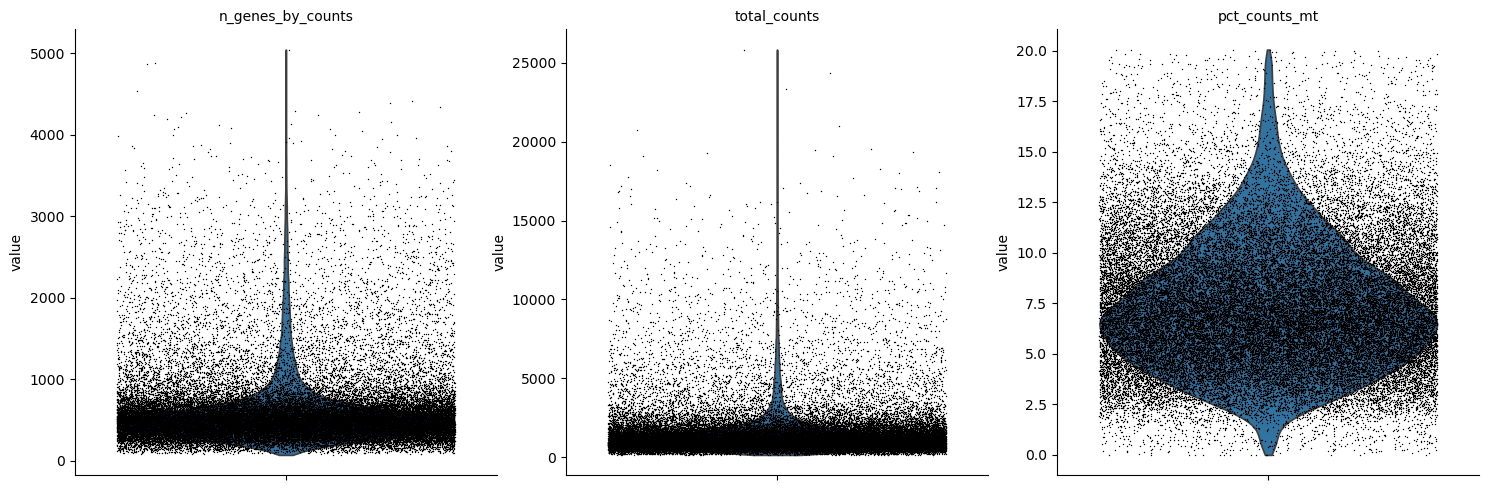

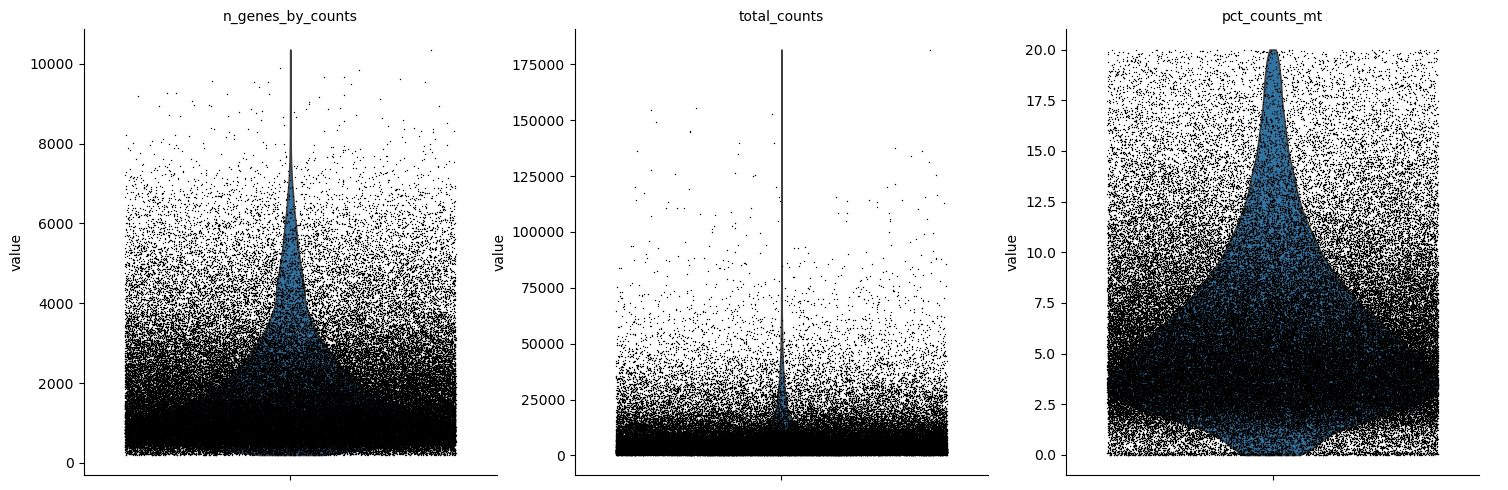

In [5]:
sc.pl.violin(
    adata1,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

sc.pl.violin(
    adata2,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

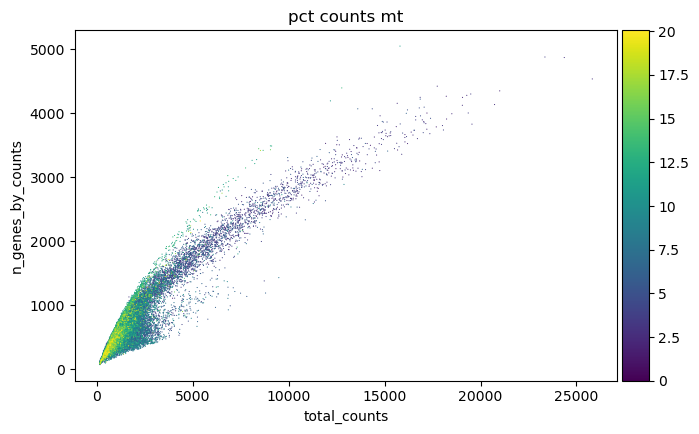

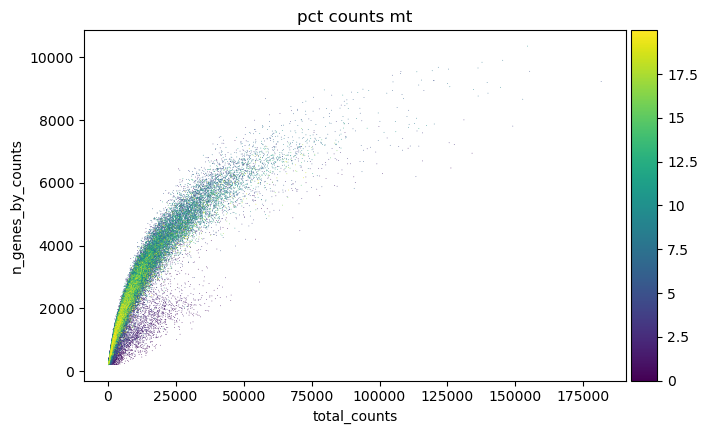

In [6]:
sc.pl.scatter(
    adata1,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt"
)

sc.pl.scatter(
    adata2,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt"
)

In [7]:
print("Before QC filtering:")
print("GSE114725:", adata1.n_obs, "cells,", adata1.n_vars, "genes")
print("GSE176078:", adata2.n_obs, "cells,", adata2.n_vars, "genes")

Before QC filtering:
GSE114725: 47016 cells, 14875 genes
GSE176078: 100064 cells, 29733 genes


In [8]:
# Dataset-specific QC thresholds based on inspected distributions

adata1 = adata1[
    (adata1.obs["n_genes_by_counts"] >= 200) &
    (adata1.obs["pct_counts_mt"] < 10),
    :
].copy()

adata2 = adata2[
    (adata2.obs["n_genes_by_counts"] >= 300) &
    (adata2.obs["pct_counts_mt"] < 10),
    :
].copy()

print("After cell filtering:")
print("GSE114725:", adata1.n_obs, "cells")
print("GSE176078:", adata2.n_obs, "cells")

After cell filtering:
GSE114725: 36633 cells
GSE176078: 83052 cells


In [9]:
sc.pp.filter_genes(adata1, min_cells=3)
sc.pp.filter_genes(adata2, min_cells=3)

print("After gene filtering:")
print("GSE114725:", adata1.n_obs, "cells,", adata1.n_vars, "genes")
print("GSE176078:", adata2.n_obs, "cells,", adata2.n_vars, "genes")

After gene filtering:
GSE114725: 36633 cells, 14751 genes
GSE176078: 83052 cells, 27221 genes


In [10]:
for adata in [adata1, adata2]:
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

print("Normalization complete.")

Normalization complete.


In [1]:
!pip install scrublet

  Using cached scrublet-0.2.3-py3-none-any.whl.metadata (3.1 kB)
  Using cached cython-3.2.4-cp313-cp313-win_amd64.whl.metadata (7.7 kB)
  Using cached annoy-1.17.3.tar.gz (647 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Using cached scrublet-0.2.3-py3-none-any.whl (15 kB)
Using cached cython-3.2.4-cp313-cp313-win_amd64.whl (2.8 MB)
  Created wheel for annoy: filename=annoy-1.17.3-cp313-cp313-win_amd64.whl size=55689 sha256=622704b1ab9ec417097cfe12053fc45097476e54c867f82b2e55e2629bc1ab0b
  Stored in directory: c:\users\annam\appdata\local\pip\cache\wheels\fc\4e\87\f1f957e7382aa370452cff98276f51686924d5415e449800ed
Successfully built annoy

   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   ------------- -------------------------- 1/3 [cython]
   --

  DEPRECATION: Building 'annoy' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'annoy'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [2]:
import scrublet as scr